In [1]:
# ============================================================
# FULL FARMLAND BOUNDARY TRAINING PIPELINE
# ============================================================

import os
import cv2
import torch
import random
import numpy as np
import xml.etree.ElementTree as ET

from glob import glob
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import segmentation_models_pytorch as smp

# ============================================================
# PATHS
# ============================================================

# ---------------- TRAIN SET 1 ----------------

TRAIN1_IMAGES = r"D:\farmland boundary\New folder\Train\farmlands"

TRAIN1_XML = r"D:\farmland boundary\New folder\Train\boundary mask\annotations.xml"

# ---------------- TRAIN SET 2 ----------------

TRAIN2_IMAGES = r"D:\farmland boundary\New folder\Train 2\images"

TRAIN2_XML = r"D:\farmland boundary\New folder\Train 2\boundarydet\annotations.xml"

# ---------------- PREDICTION IMAGES ----------------

PREDICT_IMAGES = r"D:\farmland boundary\New folder\images"

# ---------------- OUTPUTS ----------------

MASK_FOLDER = r"D:\farmland boundary\all_boundary_masks"

PREDICTION_FOLDER = r"D:\farmland boundary\final_predictions"

MODEL_PATH = r"D:\farmland boundary\boundary_model.pth"

os.makedirs(MASK_FOLDER, exist_ok=True)

os.makedirs(PREDICTION_FOLDER, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================

IMAGE_SIZE = 512

BATCH_SIZE = 2

EPOCHS = 120

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nUsing device: {DEVICE}")

# ============================================================
# FUNCTION TO CREATE MASKS FROM XML
# ============================================================

def create_masks(xml_path):

    tree = ET.parse(xml_path)

    root = tree.getroot()

    count = 0

    for image_tag in root.findall("image"):

        filename = image_tag.attrib["name"]

        width = int(float(image_tag.attrib["width"]))

        height = int(float(image_tag.attrib["height"]))

        # black background
        mask = np.zeros((height, width), dtype=np.uint8)

        # ====================================================
        # DRAW BOUNDARIES
        # ====================================================

        for poly in image_tag.findall("polygon"):

            label = poly.attrib.get("label", "")

            if label != "farmland":
                continue

            points_str = poly.attrib["points"]

            points = []

            for p in points_str.split(";"):

                x, y = map(float, p.split(","))

                points.append([int(x), int(y)])

            points = np.array(points, dtype=np.int32)

            # draw boundary only
            cv2.polylines(
                mask,
                [points],
                isClosed=True,
                color=255,
                thickness=2
            )

        save_path = os.path.join(
            MASK_FOLDER,
            os.path.splitext(filename)[0] + ".png"
        )

        cv2.imwrite(save_path, mask)

        count += 1

    return count

# ============================================================
# CREATE ALL MASKS
# ============================================================

print("\n===================================")
print("CREATING MASKS")
print("===================================")

count1 = create_masks(TRAIN1_XML)

count2 = create_masks(TRAIN2_XML)

print(f"\nTrain1 masks: {count1}")

print(f"Train2 masks: {count2}")

# ============================================================
# DATASET
# ============================================================

class FarmlandDataset(Dataset):

    def __init__(self, image_folders, mask_folder):

        self.samples = []

        for folder in image_folders:

            image_paths = sorted(
                glob(os.path.join(folder, "*.jpg")) +
                glob(os.path.join(folder, "*.png")) +
                glob(os.path.join(folder, "*.jpeg"))
            )

            for image_path in image_paths:

                filename = os.path.basename(image_path)

                mask_name = (
                    os.path.splitext(filename)[0] + ".png"
                )

                mask_path = os.path.join(
                    mask_folder,
                    mask_name
                )

                if os.path.exists(mask_path):

                    self.samples.append(
                        (image_path, mask_path)
                    )

        print(f"\nValid training pairs: {len(self.samples)}")

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image_path, mask_path = self.samples[idx]

        # ====================================================
        # IMAGE
        # ====================================================

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ====================================================
        # MASK
        # ====================================================

        mask = cv2.imread(mask_path, 0)

        # ====================================================
        # RESIZE
        # ====================================================

        image = cv2.resize(
            image,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        mask = cv2.resize(
            mask,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        # ====================================================
        # NORMALIZE
        # ====================================================

        image = self.transform(image)

        mask = torch.tensor(
            mask / 255.0
        ).float().unsqueeze(0)

        return image, mask

# ============================================================
# LOAD DATASET
# ============================================================

dataset = FarmlandDataset(

    [TRAIN1_IMAGES, TRAIN2_IMAGES],

    MASK_FOLDER
)

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True
)

# ============================================================
# MODEL
# ============================================================

print("\n===================================")
print("LOADING MODEL")
print("===================================")

model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1
)

model = model.to(DEVICE)

# ============================================================
# LOSS
# ============================================================

loss_fn = torch.nn.BCEWithLogitsLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3
)

# ============================================================
# TRAINING
# ============================================================

print("\n===================================")
print("TRAINING STARTED")
print("===================================\n")

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {total_loss:.4f}"
    )

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(

    model.state_dict(),

    MODEL_PATH
)

print("\nMODEL SAVED")

# ============================================================
# PREDICTION
# ============================================================

print("\n===================================")
print("PREDICTING BOUNDARIES")
print("===================================\n")

model.eval()

predict_images = sorted(
    glob(os.path.join(PREDICT_IMAGES, "*.jpg")) +
    glob(os.path.join(PREDICT_IMAGES, "*.png")) +
    glob(os.path.join(PREDICT_IMAGES, "*.jpeg"))
)

transform = transforms.Compose([
    transforms.ToTensor()
])

with torch.no_grad():

    for image_path in tqdm(predict_images):

        image = cv2.imread(image_path)

        if image is None:
            continue

        h, w = image.shape[:2]

        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        tensor = transform(resized)

        tensor = tensor.unsqueeze(0).to(DEVICE)

        # ====================================================
        # PREDICT
        # ====================================================

        pred = model(tensor)

        pred = torch.sigmoid(pred)

        pred = pred.squeeze().cpu().numpy()

        # ====================================================
        # THRESHOLD
        # ====================================================

        pred = (pred > 0.2).astype(np.uint8)

        pred = pred * 255

        # ====================================================
        # CLEAN SMALL NOISE
        # ====================================================

        kernel = np.ones((2,2), np.uint8)

        pred = cv2.morphologyEx(
            pred,
            cv2.MORPH_OPEN,
            kernel
        )

        # ====================================================
        # RESIZE BACK
        # ====================================================

        pred = cv2.resize(
            pred,
            (w, h)
        )

        # ====================================================
        # SAVE
        # ====================================================

        filename = os.path.basename(image_path)

        save_path = os.path.join(
            PREDICTION_FOLDER,
            os.path.splitext(filename)[0] + "_pred.png"
        )

        cv2.imwrite(save_path, pred)

print("\n===================================")
print("ALL PREDICTIONS COMPLETE")
print("===================================")


Using device: cpu

CREATING MASKS

Train1 masks: 10
Train2 masks: 47

Valid training pairs: 53

LOADING MODEL

TRAINING STARTED

Epoch 1/120 Loss: 7.8194
Epoch 2/120 Loss: 5.0485
Epoch 3/120 Loss: 4.5555
Epoch 4/120 Loss: 4.3786
Epoch 5/120 Loss: 4.2708
Epoch 6/120 Loss: 4.2423
Epoch 7/120 Loss: 4.1110
Epoch 8/120 Loss: 4.1056
Epoch 9/120 Loss: 4.0840
Epoch 10/120 Loss: 4.0390
Epoch 11/120 Loss: 3.9098
Epoch 12/120 Loss: 3.9135
Epoch 13/120 Loss: 3.8574
Epoch 14/120 Loss: 3.7990
Epoch 15/120 Loss: 3.8272
Epoch 16/120 Loss: 3.7688
Epoch 17/120 Loss: 3.6845
Epoch 18/120 Loss: 3.5837
Epoch 19/120 Loss: 3.6152
Epoch 20/120 Loss: 3.6001
Epoch 21/120 Loss: 3.4826
Epoch 22/120 Loss: 3.4787
Epoch 23/120 Loss: 3.4725
Epoch 24/120 Loss: 3.3890
Epoch 25/120 Loss: 3.3429
Epoch 26/120 Loss: 3.2453
Epoch 27/120 Loss: 3.1795
Epoch 28/120 Loss: 3.1745
Epoch 29/120 Loss: 3.2695
Epoch 30/120 Loss: 3.1581
Epoch 31/120 Loss: 3.0635
Epoch 32/120 Loss: 3.0997
Epoch 33/120 Loss: 3.0236
Epoch 34/120 Loss: 2.

100%|████████████████████████████████████████████████████████████████████████████████| 268/268 [01:54<00:00,  2.34it/s]


ALL PREDICTIONS COMPLETE



Ground truth masks found: 57

Calculating metrics...



 16%|█████████████                                                                      | 9/57 [00:00<00:00, 87.65it/s]

Prediction missing for: 1 - Copy.png
Prediction missing for: 100 - Copy.png
Prediction missing for: 101 - Copy.png
Prediction missing for: 102.png
Prediction missing for: 107.png
Prediction missing for: 112.png
Prediction missing for: 113.png
Prediction missing for: 114.png
Prediction missing for: 144.png
Prediction missing for: 146.png


100%|█████████████████████████████████████████████████████████████████████████████████| 57/57 [00:00<00:00, 207.54it/s]


Prediction missing for: 155.png
Prediction missing for: 157.png
Prediction missing for: 159.png
Prediction missing for: 161.png
Prediction missing for: 163.png
Prediction missing for: 170.png
Prediction missing for: 171.png
Prediction missing for: 179.png
Prediction missing for: 180.png
Prediction missing for: 187.png
Prediction missing for: 194.png
Prediction missing for: 197.png
Prediction missing for: 198.png
Prediction missing for: 199 - Copy.png
Prediction missing for: 200 - Copy.png
Prediction missing for: 201 - Copy.png
Prediction missing for: 202 - Copy.png
Prediction missing for: 203.png
Prediction missing for: 204.png
Prediction missing for: 205.png
Prediction missing for: 206.png
Prediction missing for: 29 - Copy.png
Prediction missing for: 30 - Copy.png
Prediction missing for: 35 - Copy.png
Prediction missing for: 36 - Copy.png
Prediction missing for: 37 - Copy.png
Prediction missing for: 38 - Copy.png
Prediction missing for: 39 - Copy.png
Prediction missing for: 40 - Copy.

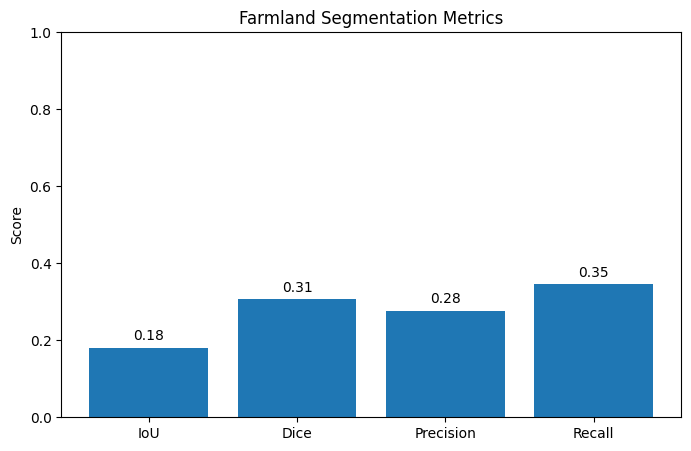

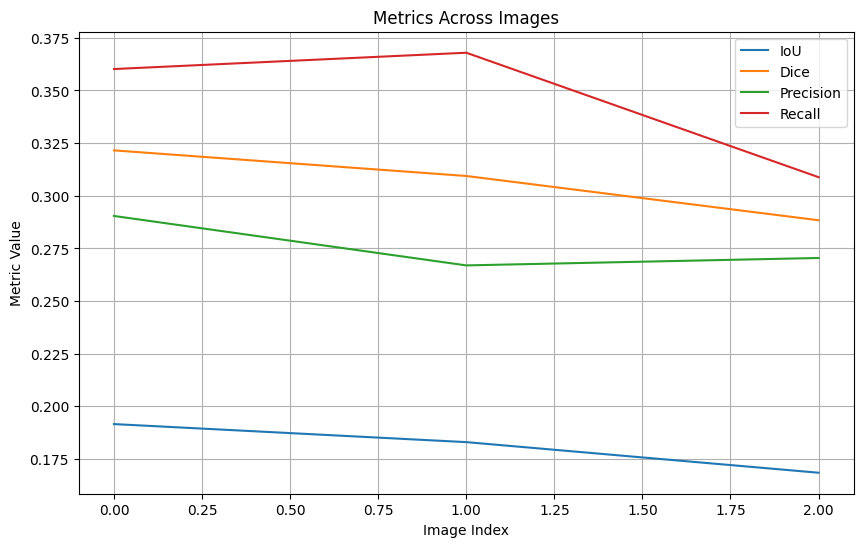

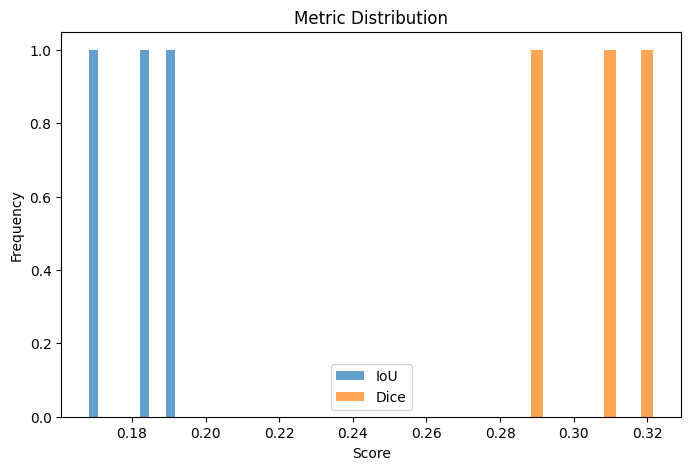


EVALUATION COMPLETE


In [1]:
# ============================================================
# FARMLAND SEGMENTATION METRICS + GRAPHS
# ============================================================

# METRICS:
# 1. IoU
# 2. Dice Score
# 3. Precision
# 4. Recall
#
# INPUT:
# Ground Truth Masks Folder
# Predicted Masks Folder
#
# OUTPUT:
# - printed metrics
# - metric graphs
# - comparison plots
#
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================

GROUND_TRUTH_FOLDER = r"D:\farmland boundary\all_boundary_masks"

PREDICTED_FOLDER = r"D:\farmland boundary\final_predictions"

# ============================================================
# LOAD FILES
# ============================================================

gt_paths = sorted(glob(os.path.join(GROUND_TRUTH_FOLDER, "*.png")))

print(f"\nGround truth masks found: {len(gt_paths)}")

# ============================================================
# METRIC FUNCTIONS
# ============================================================

def calculate_iou(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union


def calculate_dice(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    total = y_true.sum() + y_pred.sum()

    if total == 0:
        return 1.0

    return (2 * intersection) / total


def calculate_precision(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fp = np.logical_and(y_true == 0, y_pred == 1).sum()

    if (tp + fp) == 0:
        return 1.0

    return tp / (tp + fp)


def calculate_recall(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fn = np.logical_and(y_true == 1, y_pred == 0).sum()

    if (tp + fn) == 0:
        return 1.0

    return tp / (tp + fn)

# ============================================================
# STORE RESULTS
# ============================================================

ious = []
dices = []
precisions = []
recalls = []

# ============================================================
# EVALUATE
# ============================================================

print("\nCalculating metrics...\n")

for gt_path in tqdm(gt_paths):

    filename = os.path.basename(gt_path)

    pred_path = os.path.join(
        PREDICTED_FOLDER,
        filename.replace(".png", "_pred.png")
    )

    if not os.path.exists(pred_path):

        print(f"Prediction missing for: {filename}")
        continue

    # ========================================================
    # LOAD MASKS
    # ========================================================

    gt = cv2.imread(gt_path, 0)

    pred = cv2.imread(pred_path, 0)

    # ========================================================
    # RESIZE IF NEEDED
    # ========================================================

    pred = cv2.resize(
        pred,
        (gt.shape[1], gt.shape[0])
    )

    # ========================================================
    # BINARIZE
    # ========================================================

    gt = (gt > 127).astype(np.uint8)

    pred = (pred > 127).astype(np.uint8)

    # ========================================================
    # METRICS
    # ========================================================

    iou = calculate_iou(gt, pred)

    dice = calculate_dice(gt, pred)

    precision = calculate_precision(gt, pred)

    recall = calculate_recall(gt, pred)

    # ========================================================
    # STORE
    # ========================================================

    ious.append(iou)

    dices.append(dice)

    precisions.append(precision)

    recalls.append(recall)

# ============================================================
# AVERAGES
# ============================================================

avg_iou = np.mean(ious)

avg_dice = np.mean(dices)

avg_precision = np.mean(precisions)

avg_recall = np.mean(recalls)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===================================")
print("SEGMENTATION METRICS")
print("===================================\n")

print(f"IoU Score       : {avg_iou:.4f}")

print(f"Dice Score      : {avg_dice:.4f}")

print(f"Precision Score : {avg_precision:.4f}")

print(f"Recall Score    : {avg_recall:.4f}")

# ============================================================
# BAR GRAPH
# ============================================================

metrics = [
    "IoU",
    "Dice",
    "Precision",
    "Recall"
]

values = [
    avg_iou,
    avg_dice,
    avg_precision,
    avg_recall
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.ylim(0, 1)

plt.ylabel("Score")

plt.title("Farmland Segmentation Metrics")

# add value labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

# ============================================================
# METRIC DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(ious, label="IoU")

plt.plot(dices, label="Dice")

plt.plot(precisions, label="Precision")

plt.plot(recalls, label="Recall")

plt.xlabel("Image Index")

plt.ylabel("Metric Value")

plt.title("Metrics Across Images")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# HISTOGRAMS
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(ious, bins=10, alpha=0.7, label="IoU")

plt.hist(dices, bins=10, alpha=0.7, label="Dice")

plt.xlabel("Score")

plt.ylabel("Frequency")

plt.title("Metric Distribution")

plt.legend()

plt.show()

print("\n===================================")
print("EVALUATION COMPLETE")
print("===================================")